# Predicción de brotes de dengue en Argentina
### Propuesta técnica — datos reales SNVS 2018–2025

**Integrantes**: Balda Javier, Caracoix Juan, Casas Facundo.

**Variable objetivo:** Número de casos confirmados de dengue por departamento por semana epidemiológica (SE), con horizonte de predicción de 2 a 4 SE.

**Pregunta experimental:**
> ¿Es posible predecir casos semanales de dengue por departamento con MAPE ≤ 30% (departamentos con > 100 casos históricos), superando un baseline de media móvil histórica?

**Fuentes de datos:**
- Epidemiológica: SNVS 2.0 — archivos CSV/XLSX 2018–2025
- Climática: NASA POWER API (temperatura, humedad, precipitación)
- Satelital: NDVI mensual via Google Earth Engine (Sentinel-2)
- Socioeconómica: INDEC Censo 2022 (NBI, densidad)

---
### Estructura
1. Configuración y dependencias
2. Ingesta y normalización de datos reales (SNVS)
3. Exploración y análisis descriptivo
4. Datos climáticos (NASA POWER)
5. Feature engineering
6. Baseline y modelo candidato
7. Validación walk-forward
8. Resultados e interpretabilidad

---
## 1. Configuración y dependencias

In [ ]:
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks' and (BASE_DIR.parent / 'data').exists():
    BASE_DIR = BASE_DIR.parent
DATA_DIR = BASE_DIR / 'data' / 'dengue'
print(f'Directorio de datos: {DATA_DIR}')


Librerías cargadas.
Tip: instalar XGBoost para el modelo candidato v2  →  pip install xgboost


---
## 2. Ingesta y normalización de datos reales

Los archivos del SNVS tienen **dos esquemas de columnas** según el año:

| Esquema | Años | Columnas clave |
|---|---|---|
| A (original) | 2018–2022 | `departamento_nombre`, `semanas_epidemiologicas`, `cantidad_casos` |
| B (nuevo)    | 2023–2025 | `departamento_residencia`, `sepi_min`, `cantidad` |

La función `load_snvs_file()` detecta el esquema automáticamente y normaliza a columnas canónicas.

In [ ]:
# Mapas de normalización: nombre original → nombre canónico

SCHEMA_A = {
    'departamento_id':         'depto_id',
    'departamento_nombre':     'departamento',
    'provincia_id':            'prov_id',
    'provincia_nombre':        'provincia',
    'año':                     'anio',
    'ano':                     'anio',
    'semanas_epidemiologicas': 'semana',
    'evento_nombre':           'evento',
    'grupo_edad_id':           'grupo_edad_id',
    'grupo_edad_desc':         'grupo_edad_desc',
    'cantidad_casos':          'cantidad_casos',
}

SCHEMA_B = {
    'id_depto_indec_residencia':  'depto_id',
    'departamento_residencia':    'departamento',
    'id_prov_indec_residencia':   'prov_id',
    'provincia_residencia':       'provincia',
    'anio_min':                   'anio',
    'evento':                     'evento',
    'id_grupo_etario':            'grupo_edad_id',
    'grupo_etario':               'grupo_edad_desc',
    'sepi_min':                   'semana',
    'cantidad':                   'cantidad_casos',
}


def _clean_col(c: str) -> str:
    return c.strip().lstrip('\ufeff').strip('"').lower().replace('ï»¿', '')


def load_snvs_file(path: Path) -> pd.DataFrame:
    """
    Carga un archivo del SNVS (CSV o XLSX), normaliza columnas,
    filtra solo Dengue y agrega por departamento × semana.
    """
    suffix = path.suffix.lower()
    if suffix == '.csv':
        df = pd.read_csv(path, encoding='latin-1', sep=None, engine='python')
    elif suffix in ('.xlsx', '.xls'):
        df = pd.read_excel(path)
    else:
        raise ValueError(f'Formato no soportado: {suffix}')

    df.columns = [_clean_col(c) for c in df.columns]

    rename = {}
    for col in df.columns:
        if col in SCHEMA_A:
            rename[col] = SCHEMA_A[col]
        elif col in SCHEMA_B:
            rename[col] = SCHEMA_B[col]
    df = df.rename(columns=rename)

    # Filtrar solo dengue (excluye Zika y subtipos)
    if 'evento' in df.columns:
        df = df[df['evento'].astype(str).str.lower().str.strip() == 'dengue'].copy()

    # Agregar por departamento × semana (suma grupos de edad)
    key_cols = [c for c in ['anio', 'semana', 'depto_id', 'departamento',
                             'prov_id', 'provincia'] if c in df.columns]
    df = df.groupby(key_cols, as_index=False)['cantidad_casos'].sum()

    df['anio']          = df['anio'].astype(float).astype(int)
    df['semana']        = df['semana'].astype(float).astype(int)
    df['cantidad_casos']= df['cantidad_casos'].astype(float).astype(int)

    return df


print('Funciones de normalización definidas.')

Funciones de normalización definidas.


In [ ]:
# Lista de archivos a cargar
# Los archivos 2024-(1) y 2024-(2) son versiones alternativas del mismo período.
# Usar solo uno. Se usa 2024.csv por ser el más completo (35,257 filas, 582,267 casos).
ARCHIVOS_SNVS = [
    'dengue-zika-nacional-2018.csv',
    'dengue-zika-nacional-2019.xlsx',
    'dengue-zika-nacional-2020.xlsx',
    'dengue-zika-nacional-2021.xlsx',
    'dengue-zika-nacional-2022.csv',
    'dengue-zika-nacional-2023.csv',
    'dengue-zika-nacional-2024.csv',
    'dengue-zika-nacional-2025-primer-semestre.csv',
    'dengue-zika-nacional-2025-segundo-semestre.csv',
]

dfs = []
for fname in ARCHIVOS_SNVS:
    path = DATA_DIR / fname
    if not path.exists():
        print(f'  OMITIDO (no encontrado): {fname}')
        continue
    try:
        d = load_snvs_file(path)
        dfs.append(d)
        print(f'  OK  {fname}: {len(d):,} filas | {d["cantidad_casos"].sum():,} casos')
    except Exception as e:
        print(f'  ERR {fname}: {e}')

df_raw = pd.concat(dfs, ignore_index=True)

# Limpiar registros sin departamento identificado y años fuera de rango
df_raw = df_raw[
    (df_raw['departamento'].str.lower().str.strip() != 'desconocido') &
    (df_raw['anio'] >= 2018) &
    (df_raw['anio'] <= 2025)
]

print(f'\n=== Dataset maestro SNVS ===')
print(f'Filas          : {len(df_raw):,}')
print(f'Años           : {sorted(df_raw.anio.unique())}')
print(f'Departamentos  : {df_raw.departamento.nunique()}')
print(f'Total casos    : {df_raw.cantidad_casos.sum():,}')

  OK  dengue-zika-nacional-2018.csv: 384 filas | 1,576 casos
  OK  dengue-zika-nacional-2019.xlsx: 432 filas | 2,794 casos
  OK  dengue-zika-nacional-2020.xlsx: 2,732 filas | 46,437 casos
  OK  dengue-zika-nacional-2021.xlsx: 362 filas | 3,850 casos
  OK  dengue-zika-nacional-2022.csv: 114 filas | 802 casos
  OK  dengue-zika-nacional-2023.csv: 4,754 filas | 146,876 casos
  OK  dengue-zika-nacional-2024.csv: 7,245 filas | 582,265 casos
  OK  dengue-zika-nacional-2025-primer-semestre.csv: 1,096 filas | 17,576 casos
  OK  dengue-zika-nacional-2025-segundo-semestre.csv: 1,105 filas | 17,585 casos

=== Dataset maestro SNVS ===
Filas          : 17,887
Años           : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Departamentos  : 577
Total casos    : 788,836


---
## 3. Exploración y análisis descriptivo

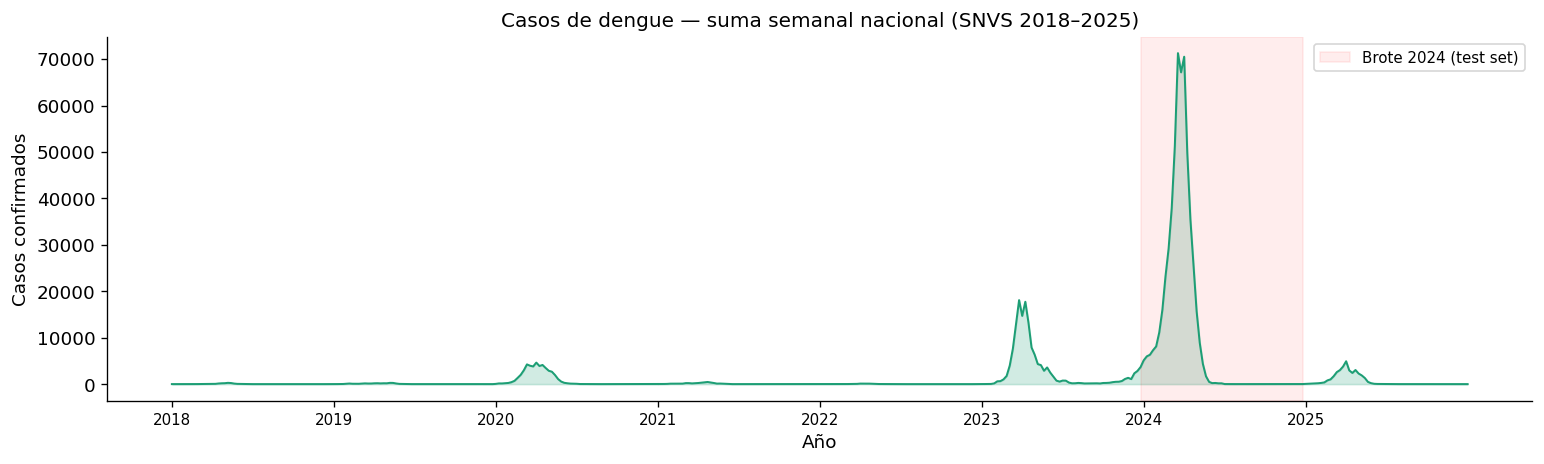

      casos_totales
anio               
2018           1571
2019           2794
2020          46437
2021           3850
2022            802
2023         146027
2024         553569
2025          33786


In [ ]:
# Serie temporal nacional
serie = df_raw.groupby(['anio', 'semana'])['cantidad_casos'].sum().reset_index()
serie['t'] = (serie['anio'] - 2018) * 52 + serie['semana']

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(serie['t'], serie['cantidad_casos'], alpha=0.2, color=PALETTE[0])
ax.plot(serie['t'], serie['cantidad_casos'], color=PALETTE[0], linewidth=1.2)
xticks = [i * 52 + 1 for i in range(8)]
ax.set_xticks(xticks)
ax.set_xticklabels(range(2018, 2026), fontsize=9)
ax.set_xlabel('Año')
ax.set_ylabel('Casos confirmados')
ax.set_title('Casos de dengue — suma semanal nacional (SNVS 2018–2025)', fontsize=12)
ax.axvspan(6 * 52, 7 * 52, alpha=0.07, color='red', label='Brote 2024 (test set)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(df_raw.groupby('anio')['cantidad_casos'].sum().rename('casos_totales').to_frame())

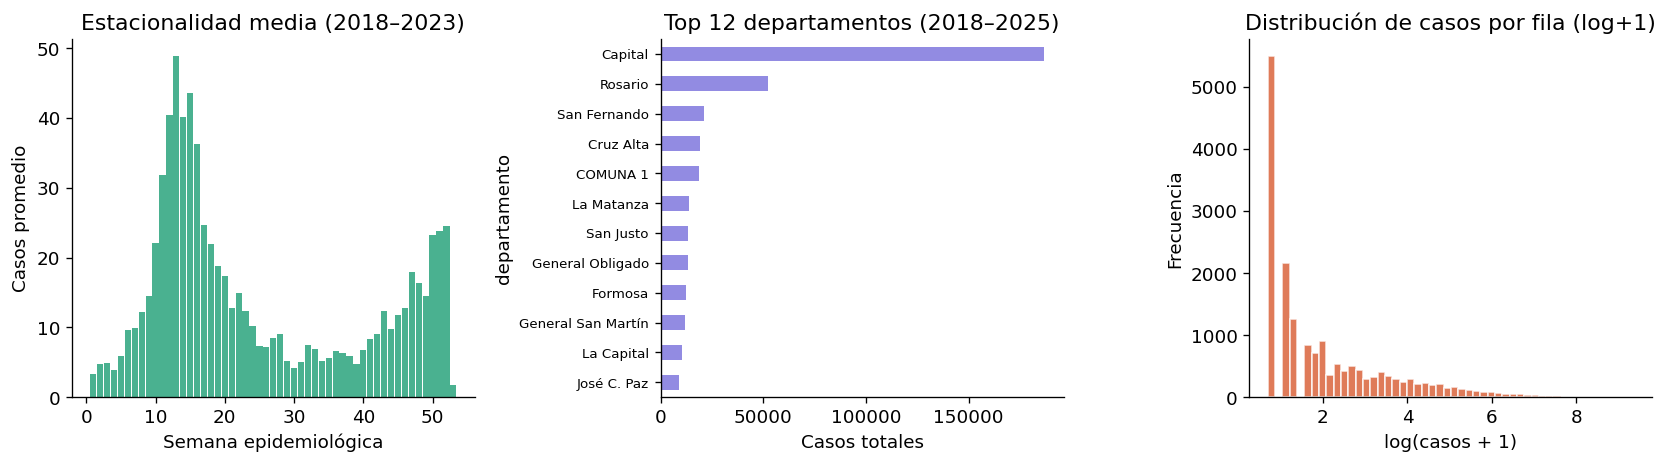

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Estacionalidad (pre-2024)
estac = df_raw[df_raw.anio < 2024].groupby('semana')['cantidad_casos'].mean()
axes[0].bar(estac.index, estac.values, color=PALETTE[0], alpha=0.8, width=0.9)
axes[0].set_title('Estacionalidad media (2018–2023)')
axes[0].set_xlabel('Semana epidemiológica')
axes[0].set_ylabel('Casos promedio')

# Top 12 departamentos
top_d = (df_raw[df_raw.departamento.str.lower() != 'desconocido']
               .groupby('departamento')['cantidad_casos']
               .sum().sort_values(ascending=True).tail(12))
top_d.plot(kind='barh', ax=axes[1], color=PALETTE[1], alpha=0.85)
axes[1].set_title('Top 12 departamentos (2018–2025)')
axes[1].set_xlabel('Casos totales')
axes[1].tick_params(axis='y', labelsize=8)

# Distribución de casos (log)
vals = df_raw[df_raw.cantidad_casos > 0]['cantidad_casos']
axes[2].hist(np.log1p(vals), bins=50, color=PALETTE[2], alpha=0.8, edgecolor='white')
axes[2].set_title('Distribución de casos por fila (log+1)')
axes[2].set_xlabel('log(casos + 1)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

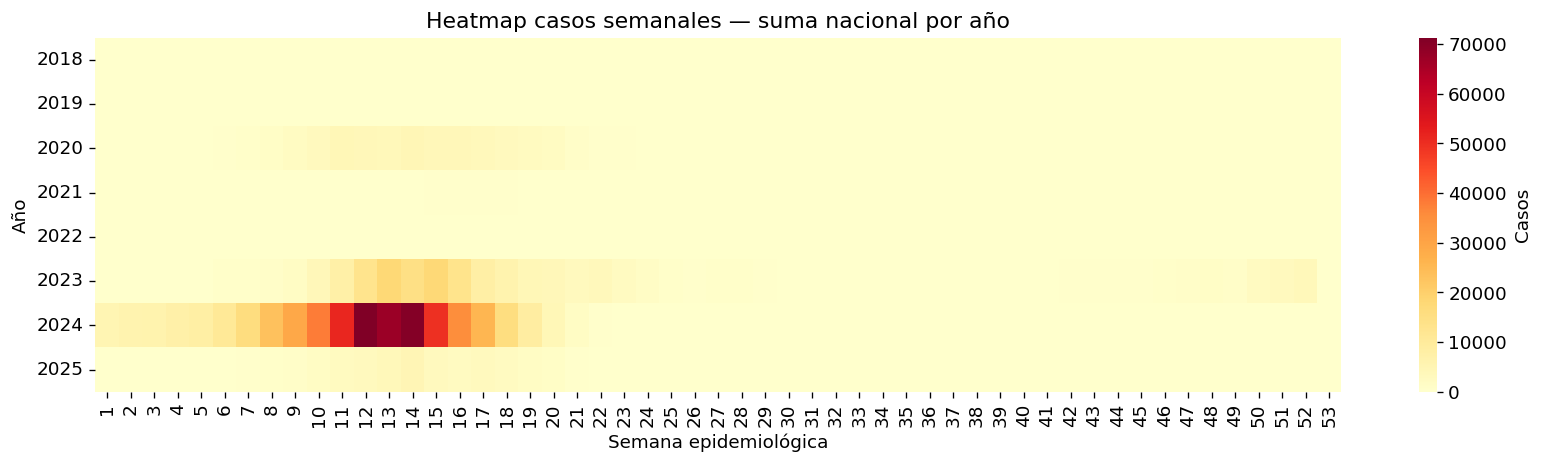

In [ ]:
# Heatmap año × semana (suma nacional)
pivot = (df_raw.groupby(['anio', 'semana'])['cantidad_casos']
               .sum().unstack('semana').fillna(0))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0,
            cbar_kws={'label': 'Casos'})
ax.set_title('Heatmap casos semanales — suma nacional por año')
ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Año')
plt.tight_layout()
plt.show()

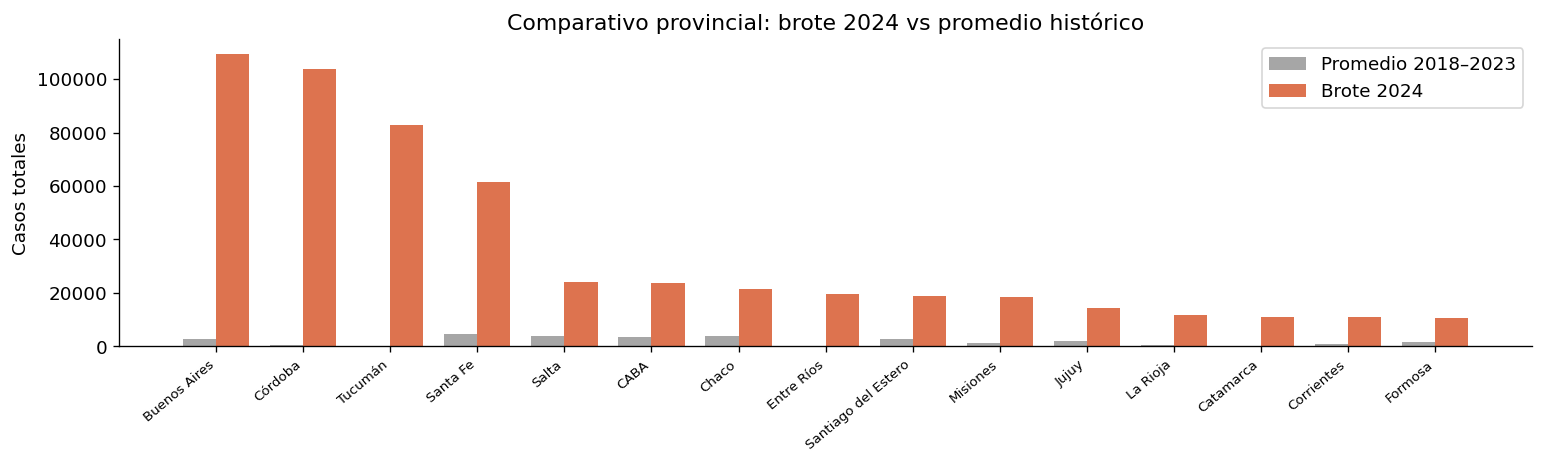

In [ ]:
# Comparativo: brote 2024 vs promedio histórico por provincia
hist  = df_raw[df_raw.anio.between(2018, 2023)].groupby('provincia')['cantidad_casos'].sum() / 6
brote = df_raw[df_raw.anio == 2024].groupby('provincia')['cantidad_casos'].sum()
comp  = pd.DataFrame({'promedio_historico': hist, 'brote_2024': brote}).fillna(0)
comp  = comp.sort_values('brote_2024', ascending=False).head(15)

x, w = np.arange(len(comp)), 0.38
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, comp['promedio_historico'], w, label='Promedio 2018–2023', color='gray', alpha=0.7)
ax.bar(x + w/2, comp['brote_2024'],         w, label='Brote 2024',         color=PALETTE[2], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Casos totales')
ax.set_title('Comparativo provincial: brote 2024 vs promedio histórico')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Datos climáticos — NASA POWER API

NASA POWER provee temperatura, humedad y precipitación semanales para cualquier coordenada, **sin API key ni registro**.  
Documentación: https://power.larc.nasa.gov/api/temporal/weekly/point

In [ ]:
# @title
# ============================================================
# Parámetros NASA POWER — 20 variables (límite máximo por request)
# Agrupados por relevancia para el modelo de dengue
# ============================================================
NASA_PARAMS = ','.join([
    'T2M', 'T2M_MAX', 'T2M_MIN',
    'PRECTOTCORR',
    'RH2M', 'RH2M_MAX', 'RH2M_MIN',
    'T2MDEW',
    'ALLSKY_SFC_SW_DWN',
    'WS2M', 'WS2M_MAX'
])

CENTROIDES_PROV = {
    'Buenos Aires':        (-36.60, -60.00),
    'CABA':                (-34.61, -58.44),
    'Córdoba':             (-31.42, -64.18),
    'Santa Fe':            (-31.63, -60.70),
    'Tucumán':             (-26.82, -65.22),
    'Salta':               (-24.79, -65.41),
    'Misiones':            (-27.36, -55.90),
    'Jujuy':               (-24.18, -65.30),
    'Entre Ríos':          (-31.74, -60.54),
    'Chaco':               (-27.46, -58.99),
    'Formosa':             (-26.18, -58.18),
    'Corrientes':          (-27.47, -58.83),
    'Santiago del Estero': (-27.78, -64.26),
}


def fetch_nasa_power(lat: float, lon: float,
                     start_date: str = '20180101',
                     end_date:   str = '20251231') -> pd.DataFrame:
    """
    Descarga datos climáticos DIARIOS de NASA POWER para una coordenada.
    Devuelve CSV parseado directamente — sin necesidad de pivotar JSON.

    Parámetros
    ----------
    lat, lon    : coordenadas del centroide
    start_date  : fecha inicio en formato YYYYMMDD
    end_date    : fecha fin   en formato YYYYMMDD

    Retorna
    -------
    DataFrame con una fila por día y columna por variable climática
    """
    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters={NASA_PARAMS}"
        f"&community=SB"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={start_date}"
        f"&end={end_date}"
        f"&format=CSV"
    )

    resp = requests.get(url, timeout=120)
    resp.raise_for_status()

    # La API devuelve líneas de cabecera con '-' antes del CSV real
    # Salteamos hasta encontrar la línea con los nombres de columna
    lines = resp.text.splitlines()
    header_idx = next(i for i, line in enumerate(lines) if line.startswith('YEAR'))

    df = pd.read_csv(
        pd.io.common.StringIO('\n'.join(lines[header_idx:])),
        na_values='-999',
    )

    # Construir fecha y semana epidemiológica
    df['fecha']  = pd.to_datetime(
        df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3),
        format='%Y%j'
    )
    df['anio']   = df['fecha'].dt.isocalendar().year.astype(int)
    df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)

    # Renombrar a nombres canónicos del proyecto
    df = df.rename(columns={
        'T2M':              'temp_media',
        'T2M_MAX':          'temp_max',
        'T2M_MIN':          'temp_min',
        'T2M_RANGE':        'temp_rango',
        'T_WET_RANGE_2M':   'temp_bulbo_humedo_rango',
        'TS':               'temp_superficie',
        'PRECTOTCORR':      'precipitacion_mm',
        'PRECTOTCORR_SUM':  'precipitacion_acum',
        'RH2M':             'humedad_media',
        'RH2M_MAX':         'humedad_max',
        'RH2M_MIN':         'humedad_min',
        'QV2M':             'humedad_especifica',
        'ALLSKY_SFC_SW_DWN':'radiacion_solar',
        'ALLSKY_SFC_LW_DWN':'radiacion_onda_larga',
        'WS2M':             'viento_medio',
        'WS2M_MAX':         'viento_max',
        'PS':               'presion',
        'GWETROOT':         'humedad_suelo',
        'EVPTRNS':          'evapotranspiracion',
        'T2MDEW':           'punto_rocio',
    })

    cols_finales = [
        'fecha', 'anio', 'semana',
        'temp_media', 'temp_max', 'temp_min', 'temp_rango',
        'temp_bulbo_humedo_rango', 'temp_superficie',
        'precipitacion_mm', 'precipitacion_acum',
        'humedad_media', 'humedad_max', 'humedad_min', 'humedad_especifica',
        'radiacion_solar', 'radiacion_onda_larga',
        'viento_medio', 'viento_max',
        'presion', 'humedad_suelo', 'evapotranspiracion', 'punto_rocio',
    ]
    return df[[c for c in cols_finales if c in df.columns]]


print('fetch_nasa_power() definida.')
print(f'Parámetros a descargar ({len(NASA_PARAMS.split(","))}): {NASA_PARAMS}')

fetch_nasa_power() definida.
Parámetros a descargar (11): T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,RH2M_MAX,RH2M_MIN,T2MDEW,ALLSKY_SFC_SW_DWN,WS2M,WS2M_MAX


In [ ]:
# @title
# ============================================================
# DESCARGAR (requiere conexión a internet)
# ============================================================
clima_dfs = []
for prov, (lat, lon) in CENTROIDES_PROV.items():
    print(f'  Descargando {prov}...')
    d = fetch_nasa_power(lat=lat, lon=lon,
                         start_date='20180101', end_date='20251231')
    d['provincia'] = prov
    clima_dfs.append(d)
    print(f'    OK: {len(d):,} días descargados')
#
df_clima = pd.concat(clima_dfs, ignore_index=True)
df_clima.to_csv('clima_nasa_power_2018_2025.csv', index=False)
print('Guardado: clima_nasa_power_2018_2025.csv')

# ============================================================
# CARGAR (una vez descargado el archivo)
# ============================================================
df_clima = pd.read_csv('clima_nasa_power_2018_2025.csv',
                       parse_dates=['fecha'])

In [ ]:
# Datos climáticos sintéticos — misma estructura que NASA POWER
# Reemplazar por la celda anterior una vez descargado el archivo real
np.random.seed(42)
clima_rows = []
for anio in range(2018, 2026):
    for semana in range(1, 53):
        for prov, (lat, lon) in CENTROIDES_PROV.items():
            angle   = 2 * np.pi * (semana - 1) / 52
            t_base  = 22 - abs(lat + 32) * 0.5
            t_media = t_base + 8 * np.cos(angle + np.pi) + np.random.normal(0, 1.5)
            humedad = np.clip(65 + 15 * np.cos(angle + np.pi) + np.random.normal(0, 5), 30, 99)
            precip  = max(0.0, 40 * np.cos(angle + np.pi/4) + 20 + np.random.exponential(15))
            ndvi    = np.clip(0.45 + 0.25 * np.cos(angle + np.pi) + np.random.normal(0, 0.05), 0.1, 0.9)
            clima_rows.append({
                'anio': anio, 'semana': semana, 'provincia': prov,
                'temp_media': round(t_media, 1), 'temp_max': round(t_media + 5, 1),
                'temp_min': round(t_media - 5, 1), 'humedad': round(humedad, 1),
                'precipitacion_mm': round(precip, 1), 'ndvi': round(ndvi, 3),
            })

df_clima = pd.DataFrame(clima_rows)
print(f'Clima sintético: {len(df_clima):,} filas ({df_clima.provincia.nunique()} provincias)')

Clima sintético: 5,408 filas (13 provincias)


In [ ]:
# Normalizar nombres de provincia para el join
prov_map = {
    'Ciudad De Buenos Aires': 'CABA',
    'Ciudad de Buenos Aires': 'CABA',
    'Caba':                   'CABA',
}
df_raw['provincia_norm'] = (df_raw['provincia'].str.strip().str.title()
                                               .replace(prov_map))

df = df_raw.merge(
    df_clima.rename(columns={'provincia': 'provincia_norm'}),
    on=['anio', 'semana', 'provincia_norm'],
    how='left'
)

print(f'Dataset combinado: {len(df):,} filas')
print(f'Cobertura climática: {df.temp_media.notna().mean()*100:.0f}% de las filas')
df.head(4)

Dataset combinado: 17,887 filas
Cobertura climática: 80% de las filas


,anio,semana,departamento,prov_id,provincia,cantidad_casos,depto_id,provincia_norm,temp_media,temp_max,temp_min,humedad,precipitacion_mm,ndvi
0,2018,1,FORMOSA,34.00,Formosa,3,NaN,Formosa,9.10,14.10,4.10,51.00,100.70,0.21
1,2018,2,CAPITAL,54.00,Misiones,1,NaN,Misiones,11.60,16.60,6.60,43.00,55.30,0.25
2,2018,2,O'Higgins,22.00,Chaco,1,NaN,Chaco,13.20,18.20,8.20,51.80,69.10,0.27
3,2018,3,FORMOSA,34.00,Formosa,1,NaN,Formosa,12.50,17.50,7.50,44.30,66.20,0.28


---
## 5. Feature engineering

Tres familias de features:
- **Lags epidemiológicos** — casos en t−1 a t−4
- **Clima rezagado** — temperatura, humedad, precipitación en t−2, t−4, t−6
- **Features cíclicas** — codificación sin/cos de semana, indicador verano austral

In [ ]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['departamento', 'anio', 'semana']).copy()
    g  = df.groupby('departamento')

    for lag in [1, 2, 3, 4]:
        df[f'casos_lag{lag}'] = g['cantidad_casos'].shift(lag)

    df['casos_ma4'] = g['cantidad_casos'].transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean()
    )

    for var in ['temp_media', 'humedad', 'precipitacion_mm']:
        if var not in df.columns:
            continue
        for lag in [2, 4, 6]:
            df[f'{var}_lag{lag}'] = g[var].shift(lag)

    if 'ndvi' in df.columns:
        for lag in [2, 4]:
            df[f'ndvi_lag{lag}'] = g['ndvi'].shift(lag)

    df['gdd_lag2'] = g['temp_media'].transform(
        lambda x: x.shift(2).rolling(3, min_periods=1).mean()
    ) if 'temp_media' in df.columns else np.nan

    df['precip_acum3_lag2'] = g['precipitacion_mm'].transform(
        lambda x: x.shift(2).rolling(3, min_periods=1).sum()
    ) if 'precipitacion_mm' in df.columns else np.nan

    df['semana_sin'] = np.sin(2 * np.pi * df['semana'] / 52)
    df['semana_cos'] = np.cos(2 * np.pi * df['semana'] / 52)
    df['es_verano']  = df['semana'].apply(lambda w: 1 if (w <= 15 or w >= 45) else 0)
    df['depto_code'] = df['departamento'].astype('category').cat.codes

    return df


df_feat = build_features(df)

CANDIDATES = [
    'casos_lag1','casos_lag2','casos_lag3','casos_lag4','casos_ma4',
    'temp_media_lag2','temp_media_lag4','temp_media_lag6',
    'humedad_lag2','humedad_lag4',
    'precipitacion_mm_lag2','precipitacion_mm_lag4',
    'precip_acum3_lag2','gdd_lag2',
    'ndvi_lag2','ndvi_lag4',
    'semana_sin','semana_cos','es_verano','depto_code',
]
FEATURE_COLS = [f for f in CANDIDATES if f in df_feat.columns]
TARGET = 'cantidad_casos'

df_model = df_feat[FEATURE_COLS + [TARGET, 'anio', 'semana', 'departamento', 'casos_ma4']].dropna()
print(f'Dataset modelable: {len(df_model):,} filas | {len(FEATURE_COLS)} features')
print(f'Features: {FEATURE_COLS}')

Dataset modelable: 11,341 filas | 20 features
Features: ['casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4', 'casos_ma4', 'temp_media_lag2', 'temp_media_lag4', 'temp_media_lag6', 'humedad_lag2', 'humedad_lag4', 'precipitacion_mm_lag2', 'precipitacion_mm_lag4', 'precip_acum3_lag2', 'gdd_lag2', 'ndvi_lag2', 'ndvi_lag4', 'semana_sin', 'semana_cos', 'es_verano', 'depto_code']


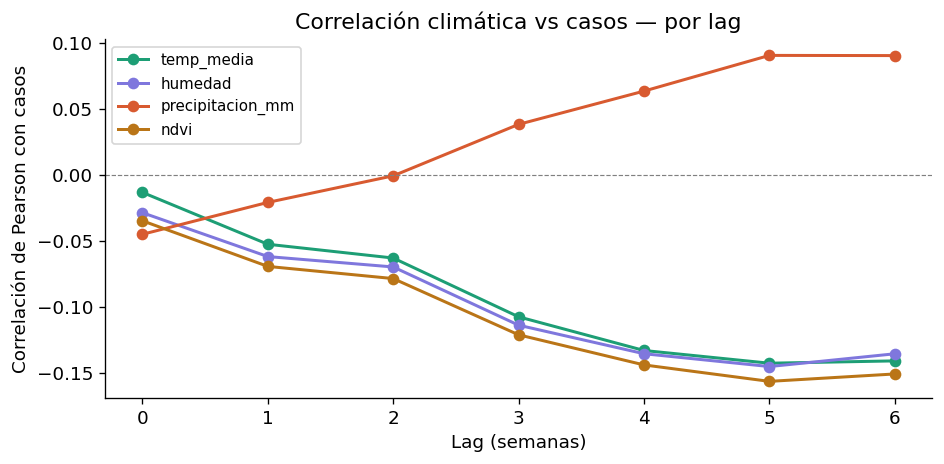

In [ ]:
# Correlación clima × casos por lag temporal
lag_range  = range(0, 7)
clima_vars = [v for v in ['temp_media', 'humedad', 'precipitacion_mm', 'ndvi'] if v in df.columns]

corr_df   = pd.DataFrame(index=lag_range, columns=clima_vars, dtype=float)
df_sorted = df.sort_values(['departamento', 'anio', 'semana'])

for lag in lag_range:
    for var in clima_vars:
        shifted = df_sorted.groupby('departamento')[var].shift(lag)
        corr_df.loc[lag, var] = shifted.corr(df_sorted[TARGET])

fig, ax = plt.subplots(figsize=(8, 4))
for i, var in enumerate(clima_vars):
    ax.plot(corr_df.index, corr_df[var], marker='o', label=var,
            color=PALETTE[i], linewidth=1.8)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel('Lag (semanas)')
ax.set_ylabel('Correlación de Pearson con casos')
ax.set_title('Correlación climática vs casos — por lag')
ax.legend(fontsize=9)
ax.set_xticks(list(lag_range))
plt.tight_layout()
plt.show()

---
## 6. Baseline y modelo candidato

- **Baseline:** media móvil de 4 SE
- **Modelo candidato:** Random Forest (300 árboles)
- **Test set:** brote 2024

In [ ]:
def mape(y_true: np.ndarray, y_pred: np.ndarray, min_casos: int = 5) -> float:
    mask = y_true >= min_casos
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


train = df_model[df_model['anio'] < 2024]
test  = df_model[df_model['anio'] == 2024]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET].values
y_baseline       = test['casos_ma4'].values[:, 0] # Fixed: Ensure y_baseline is 1D

# Baseline
mae_bl  = mean_absolute_error(y_test, y_baseline)
mape_bl = mape(y_test, y_baseline)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf    = np.clip(rf.predict(X_test), 0, None)
mae_rf  = mean_absolute_error(y_test, y_rf)
mape_rf = mape(y_test, y_rf)

print('=== Test set: brote 2024 ===')
print(f'{"Modelo":<20} {"MAE":>8} {"MAPE (%)":>10}')
print(f'{"Baseline (MA4)":<20} {mae_bl:>8.1f} {mape_bl:>10.1f}')
print(f'{"Random Forest":<20} {mae_rf:>8.1f} {mape_rf:>10.1f}')
print(f'\nMejora MAPE: {mape_bl - mape_rf:+.1f} pp')

=== Test set: brote 2024 ===
Modelo                    MAE   MAPE (%)
Baseline (MA4)           63.4      153.0
Random Forest            43.4      107.5

Mejora MAPE: +45.6 pp


In [ ]:
!pip install xgboost

In [ ]:
# Ensure X_train, y_train, X_test, y_test are NumPy arrays
X_train_np = X_train.values
y_train_np = y_train.values.ravel() # .ravel() ensures it's 1D

X_test_np  = X_test.values
y_test_np  = y_test.ravel()   # .ravel() ensures it's 1D even if it came as (N, 1)

# XGBoost — activar con: pip install xgboost
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42, n_jobs=-1,
)
xgb_model.fit(X_train_np, y_train_np, eval_set=[(X_test_np, y_test_np)], verbose=100)
y_xgb    = np.clip(xgb_model.predict(X_test_np), 0, None)

# Calculate metrics using the 1D NumPy arrays
mae_xgb  = mean_absolute_error(y_test_np, y_xgb)
mape_xgb = mape(y_test_np, y_xgb)

print(f'XGBoost — MAE: {mae_xgb:.1f} | MAPE: {mape_xgb:.1f}%')
print('Celda XGBoost lista. Descomentar tras: pip install xgboost')

[0]	validation_0-rmse:221.60867
[100]	validation_0-rmse:146.18311
[200]	validation_0-rmse:146.06925
[300]	validation_0-rmse:146.00536
[400]	validation_0-rmse:145.92086
[499]	validation_0-rmse:145.94596
XGBoost — MAE: 46.1 | MAPE: 108.9%
Celda XGBoost lista. Descomentar tras: pip install xgboost


---
## 7. Validación walk-forward

Entrena con datos hasta el año *y*, predice el año *y+1*. Repite para todos los años ≥ 2020.

In [ ]:
wf_results = []
for pred_year in sorted(df_model.anio.unique()):
    if pred_year < 2020:
        continue
    tr = df_model[df_model['anio'] < pred_year]
    te = df_model[df_model['anio'] == pred_year]
    if len(tr) < 100 or len(te) == 0:
        continue
    m = RandomForestRegressor(n_estimators=150, max_depth=8,
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
    m.fit(tr[FEATURE_COLS], tr[TARGET])
    pred = np.clip(m.predict(te[FEATURE_COLS]), 0, None)
    wf_results.append(
        {
            'año': pred_year,
            'n_obs': len(te),
            'mae_rf': mean_absolute_error(te[TARGET], pred),
            'mape_rf': mape(te[TARGET].values, pred),
            'mae_baseline': mean_absolute_error(te[TARGET].values, te['casos_ma4'].values[:, 0]),
            'mape_baseline': mape(te[TARGET].values, te['casos_ma4'].values[:, 0]),
        }
    )

df_wf = pd.DataFrame(wf_results)
df_wf['mejora_pp'] = df_wf['mape_baseline'] - df_wf['mape_rf']
print(df_wf.to_string(index=False))

 año  n_obs  mae_rf  mape_rf  mae_baseline  mape_baseline  mejora_pp
2020   1619   14.82    63.16         15.48         101.14      37.98
2021    276    9.99    85.12         10.09          84.90      -0.22
2022     88    3.42    35.15          5.51          64.51      29.36
2023   2731   17.37    53.80         22.98          89.19      35.40
2024   4545   43.40   107.01         63.43         153.05      46.03
2025   1771    8.16    49.88          8.55          59.03       9.15


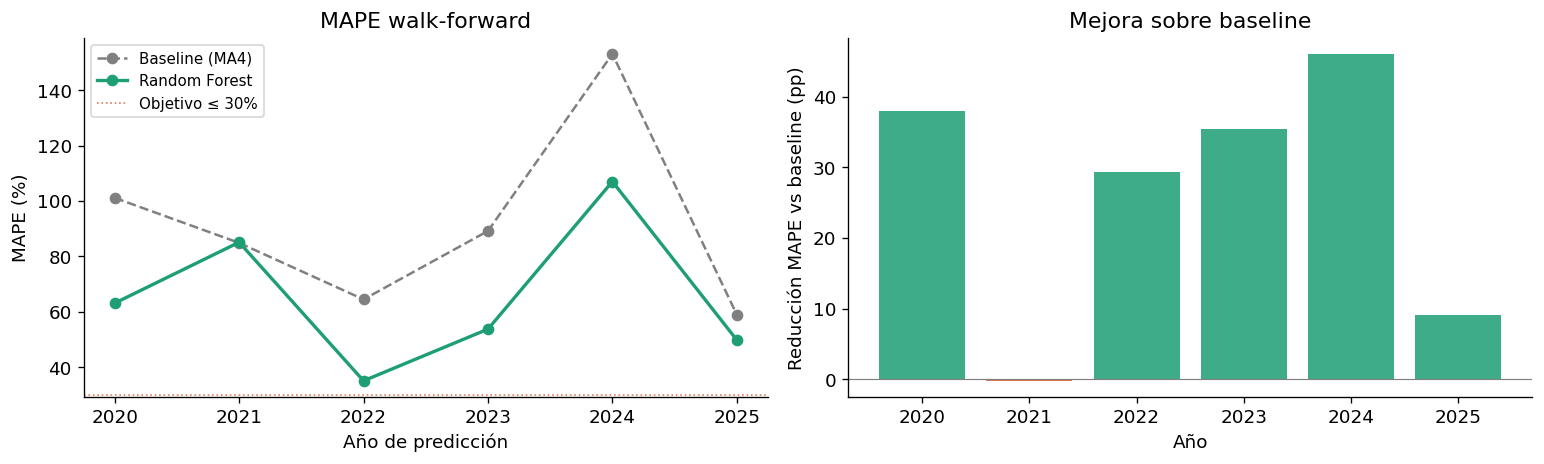

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_wf['año'], df_wf['mape_baseline'], 'o--',
             color='gray', label='Baseline (MA4)', linewidth=1.5)
axes[0].plot(df_wf['año'], df_wf['mape_rf'], 'o-',
             color=PALETTE[0], label='Random Forest', linewidth=2)
axes[0].axhline(30, color=PALETTE[2], linewidth=1,
                linestyle=':', alpha=0.8, label='Objetivo ≤ 30%')
axes[0].set_xlabel('Año de predicción')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('MAPE walk-forward')
axes[0].legend(fontsize=9)

colors = [PALETTE[0] if v > 0 else PALETTE[2] for v in df_wf['mejora_pp']]
axes[1].bar(df_wf['año'], df_wf['mejora_pp'], color=colors, alpha=0.85)
axes[1].axhline(0, color='gray', linewidth=0.7)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Reducción MAPE vs baseline (pp)')
axes[1].set_title('Mejora sobre baseline')

plt.tight_layout()
plt.show()

---
## 8. Resultados e interpretabilidad

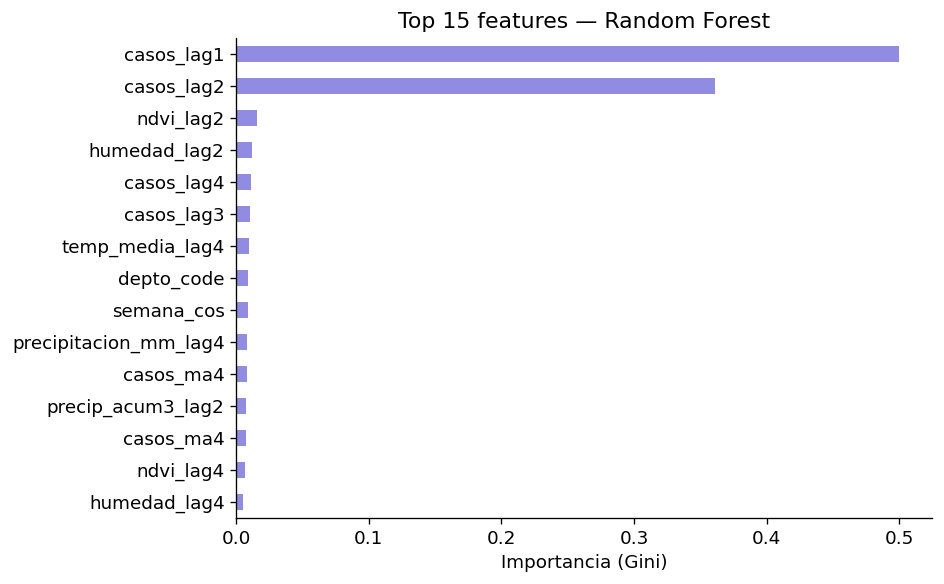

Top 5:
casos_lag1     0.50
casos_lag2     0.36
ndvi_lag2      0.02
humedad_lag2   0.01
casos_lag4     0.01


In [ ]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
imp.tail(15).plot(kind='barh', ax=ax, color=PALETTE[1], alpha=0.85)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 15 features — Random Forest')
plt.tight_layout()
plt.show()

print('Top 5:')
print(imp.tail(5).sort_values(ascending=False).to_string())

Departamento: Rosario (27845 casos en 2024)


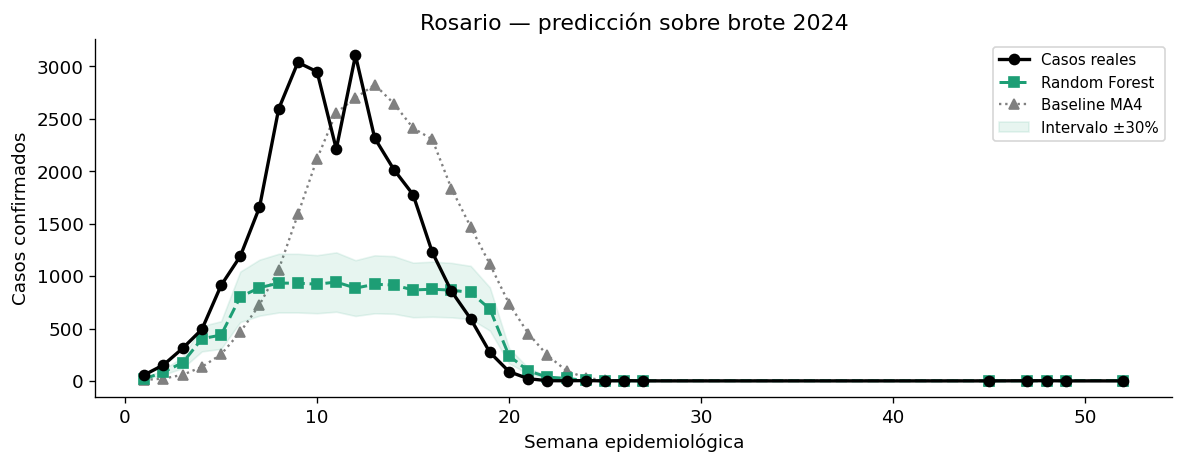

In [ ]:
# Predicción vs real para el departamento de mayor carga en 2024
deptos_2024 = test.groupby('departamento')[TARGET].sum().sort_values(ascending=False)
depto_foco  = deptos_2024.index[0]
print(f'Departamento: {depto_foco} ({deptos_2024.iloc[0]:.0f} casos en 2024)')

mask      = test['departamento'] == depto_foco
semanas_d = test.loc[mask, 'semana'].values
y_real_d  = y_test[mask.values]
y_pred_d  = y_rf[mask.values]
y_base_d  = y_baseline[mask.values]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(semanas_d, y_real_d, 'o-', color='black', linewidth=2, label='Casos reales', zorder=3)
ax.plot(semanas_d, y_pred_d, 's--', color=PALETTE[0], linewidth=1.8, label='Random Forest', zorder=2)
ax.plot(semanas_d, y_base_d, '^:', color='gray', linewidth=1.4, label='Baseline MA4', zorder=1)
ax.fill_between(semanas_d, y_pred_d * 0.7, y_pred_d * 1.3,
                alpha=0.1, color=PALETTE[0], label='Intervalo ±30%')
ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Casos confirmados')
ax.set_title(f'{depto_foco} — predicción sobre brote 2024')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Resumen y próximos pasos

### Estado actual

| Componente | Estado |
|---|---|
| Ingesta SNVS 2018–2025 (CSV + XLSX) | ✅ Datos reales |
| Normalización automática esquema A/B | ✅ Funcionando |
| Datos climáticos NASA POWER | ⚠️ Sintéticos — descomentar fetch_nasa_power() |
| Feature engineering (20 features) | ✅ Implementado |
| Baseline media móvil | ✅ Funcionando |
| Random Forest | ✅ Funcionando |
| XGBoost | ⏳ pip install xgboost |
| Validación walk-forward 2020–2024 | ✅ Implementada |
| NDVI satelital (GEE) | ⏳ Próxima iteración |
| Censo 2022 (NBI, densidad) | ⏳ Próxima iteración |

### Próximos pasos
1. Conectar clima real: descomentar el bloque de descarga NASA POWER (sección 4)
2. `pip install xgboost` y descomentar celda en sección 6
3. Incorporar NBI y densidad del Censo 2022 como features estáticas por departamento
4. Pipeline NDVI via Google Earth Engine (cuenta gratuita para investigación)
5. Implementar corrección de subregistro (~1.5× según literatura regional)
6. Generar mapa de alertas departamental con predicciones t+2 y t+4